In [9]:
#import libraries
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Set up matplotlib parameters
plt.rcParams['figure.dpi'] = 150
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**128

# Add the parent directory and modules directory to the system path
sys.path.append(os.getcwd()+'/../')
sys.path.append(os.getcwd()+'/../modules')

# Import custom modules
from Class_sem2dpack import *
from Stage_module import *


#--------------------------------------------------
#                 USER PARAMETERS
#--------------------------------------------------

# SEM2DPACK Parameters
direct1 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Stage_ISS_v10_More_Stations"
direct2 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Stage_ISS_v10_Left_Wave_Test"
is_overburden = False
fmin, fmax = 0.01, 50.0
SEM1 = sem2dpack(direct1)
SEM2 = sem2dpack(direct2)

# Notebook Parameters
save_figure = False


#--------------------------------------------------

Reading grid information...
Reading header file...
0.001 5001 90
--- No extra station ---
*
Reading grid information...
Reading header file...
0.001 5001 90
--- No extra station ---
*


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo/..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo/..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo/..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, header=0, n

In [10]:
# Function to process fault data for a given SEM object
def process_fault_data(SEM):
    fault_data = {}
    
    # Read fault data for different tags
    read_fault_testing(SEM, ftag=5)
    fault_data['Bottom'] = SEM.fault

    read_fault_testing(SEM, ftag=7)
    fault_data['Right'] = SEM.fault

    read_fault_testing(SEM, ftag=9)
    fault_data['Left'] = SEM.fault

    # Define the global orientations of the fault components
    vector_orientations = {
        'Left': (-1, -1),
        'Bottom': (-1, +1),
        'Right': (+1, +1)
    }

    # Extract the coordinates and slip values for each fault component
    fault_components = {}
    for key, data in fault_data.items():
        X_coord = data['x']
        Z_coord = data['z']
        Slip_1 = data['Slip_1']
        Slip_2 = data['Slip_2']
        orientation = 'z' if key in ['Left', 'Right'] else 'x'
        fault_components[key] = X_coord, Z_coord, Slip_1, Slip_2, orientation

    # Extract the time data (assuming it's the same for all components)
    time_fault = fault_data['Left']['Time']

    return fault_components, time_fault

# Process fault data for SEM1 and SEM2
fault_components_SEM1, time_fault_SEM1 = process_fault_data(SEM1)
fault_components_SEM2, time_fault_SEM2 = process_fault_data(SEM2)


    

DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [7] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [9] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [7] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [9] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction


In [11]:
#Desired fault locations
stations_left_fault = [12, 7, 0]
stations_bottom_fault = [0, 4, 8]
stations_right_fault = [12, 7, 0]

stations_fault_dic = {}
stations_fault_dic["Left"] = stations_left_fault
stations_fault_dic["Bottom"] = stations_bottom_fault
stations_fault_dic["Right"] = stations_right_fault

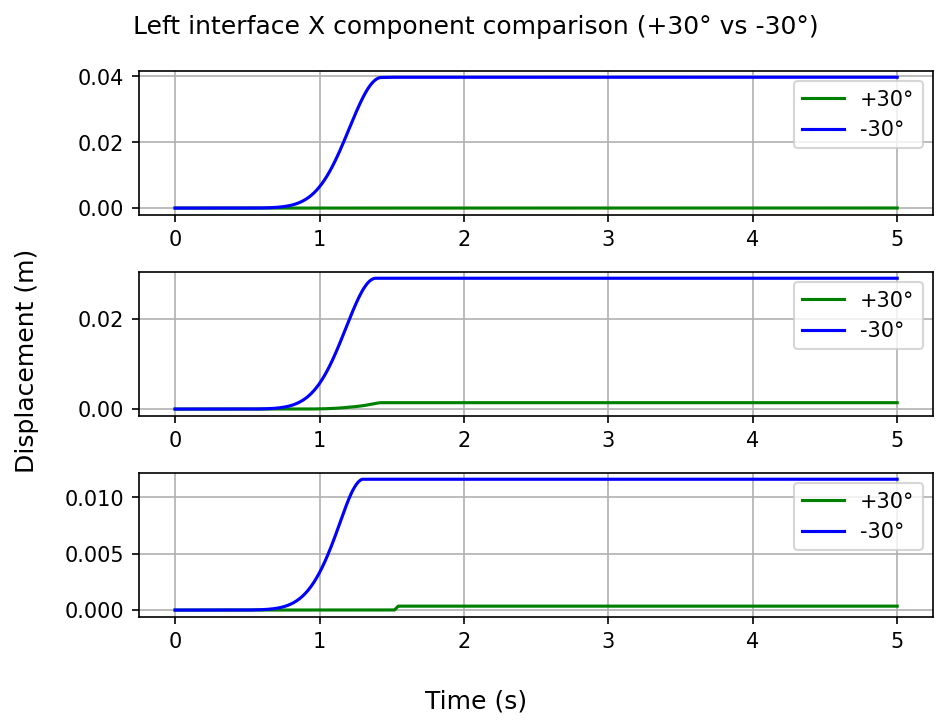

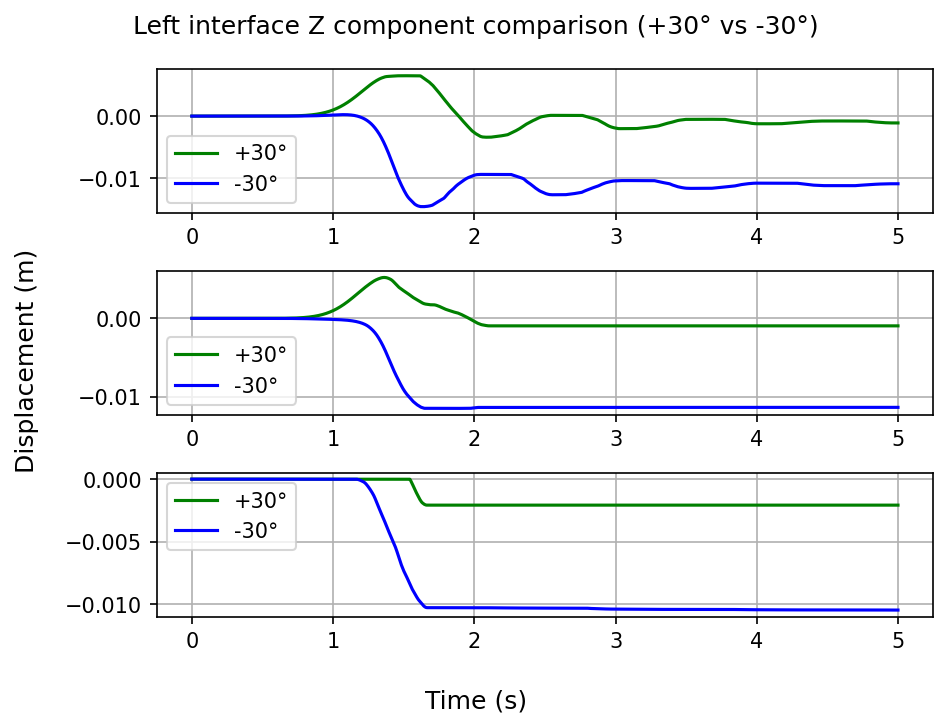

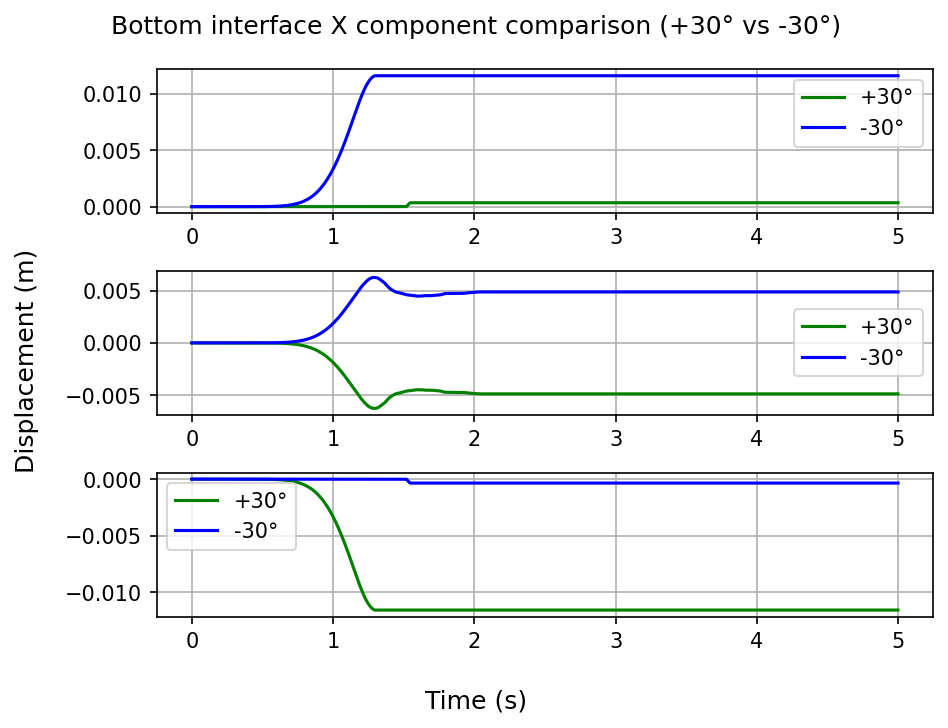

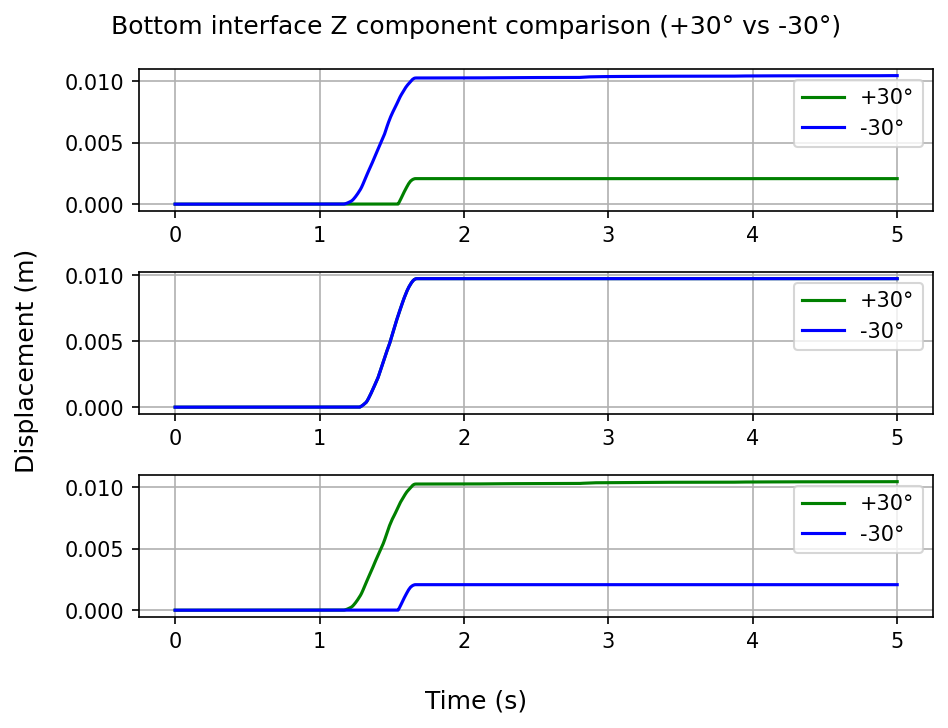

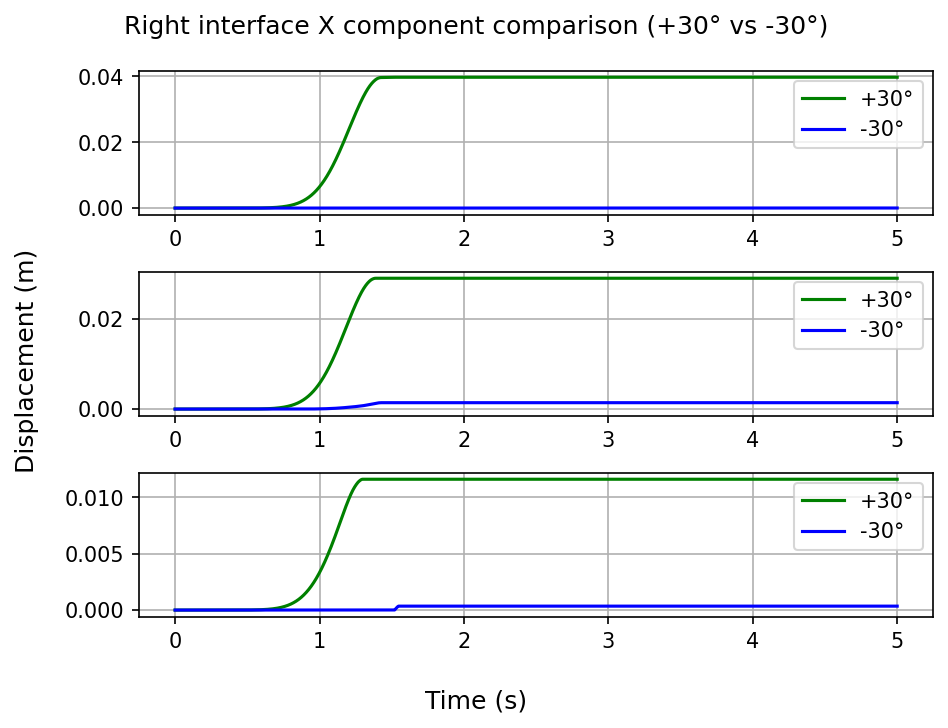

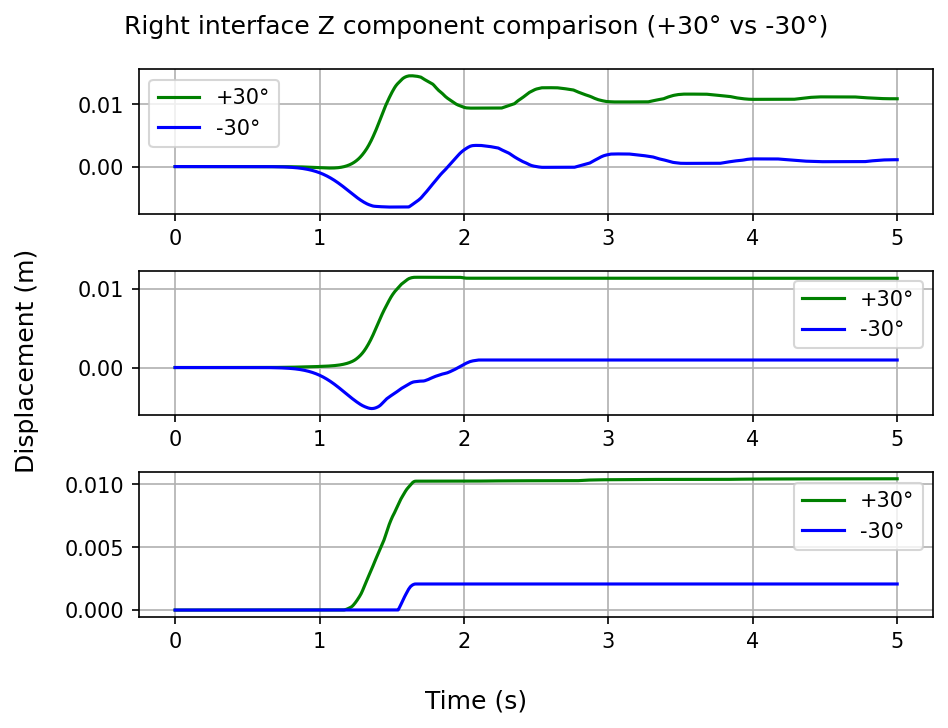

In [14]:
def plot_component_comparison(interf, comp):
    fig = plt.figure()
    fig.suptitle(f"{interf} interface {comp.upper()} component comparison (+30° vs -30°)")
    fig.supxlabel("Time (s)")
    fig.supylabel("Displacement (m)")
    
    # Extract fault components for SEM1 and SEM2
    X_coord_SEM1, Z_coord_SEM1, Slip_1_SEM1, Slip_2_SEM1, S1_dir_SEM1 = fault_components_SEM1[interf]
    X_coord_SEM2, Z_coord_SEM2, Slip_1_SEM2, Slip_2_SEM2, S1_dir_SEM2 = fault_components_SEM2[interf]
    
    for i in range(3):
        ax = fig.add_subplot(3, 1, i + 1)
        
        # Plot SEM1 data
        if S1_dir_SEM1 == comp:
            ax.plot(time_fault_SEM1, Slip_1_SEM1[stations_fault_dic[interf][i], :], label="+30°", c='green')
        else:
            ax.plot(time_fault_SEM1, Slip_2_SEM1[stations_fault_dic[interf][i], :], label="+30°", c='green')
        
        # Plot SEM2 data
        if S1_dir_SEM2 == comp:
            ax.plot(time_fault_SEM2, Slip_1_SEM2[stations_fault_dic[interf][i], :], label="-30°", c='blue')
        else:
            ax.plot(time_fault_SEM2, Slip_2_SEM2[stations_fault_dic[interf][i], :], label="-30°", c='blue')
        
        ax.legend()
        ax.grid(True)
    
    fig.tight_layout()
    plt.show()

# Plot comparisons for each interface and component
for interf in ['Left', 'Bottom', 'Right']:
    for comp in ['x', 'z']:  # Removed 'y' as it does not exist
        plot_component_comparison(interf, comp)

In [ ]:
# Read the fault data
read_fault_testing(SEM, ftag=5)
BC_bottom = SEM.fault

read_fault_testing(SEM, ftag=7)
BC_right = SEM.fault

read_fault_testing(SEM, ftag=9)
BC_left = SEM.fault


# Define the global orientations of the fault components
vector_orientations = {}
vector_orientations['Left'] = -1, -1
vector_orientations['Bottom'] = -1, +1
vector_orientations['Right'] = +1, +1

# Extract the coordinates and slip values for each fault component
X_coord_L = BC_left['x']
X_coord_B = BC_bottom['x']
X_coord_R = BC_right['x']

Z_coord_L = BC_left['z']
Z_coord_B = BC_bottom['z']
Z_coord_R = BC_right['z']

Slip_1_L = BC_left['Slip_1']
Slip_1_B = BC_bottom['Slip_1']
Slip_1_R = BC_right['Slip_1']

Slip_2_L = BC_left['Slip_2']
Slip_2_B = BC_bottom['Slip_2']
Slip_2_R = BC_right['Slip_2']

# Extract the time data
time_fault = BC_left['Time']

# Create a dictionary to hold the fault components with their respective coordinates and slip values
fault_components = {}
fault_components["Left"] = X_coord_L, Z_coord_L, Slip_1_L, Slip_2_L, 'z'
fault_components["Bottom"] = X_coord_B, Z_coord_B, Slip_1_B, Slip_2_B, 'x'
fault_components["Right"] = X_coord_R, Z_coord_R, Slip_1_R, Slip_2_R, 'z'


    

DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [7] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [9] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
